#serve_qwen.ipynb

ollama gwen ngrok

<ol>
Env prep
<li>copy .ssh from /content/drive/MyDrive/'Colab Notebooks'/.ssh to /root/.ssh. For git clone to work</li>
<li>copy the .cache dir from 'Colab Notebooks' to /root to get the HF models. This takes a while is couple G. </li>
</ol>

</ul>
<li>how to start ollama? and ngrok?</li>
<li>serving models requires ollama or vllm</li>
<li>ollama needs zstd installed</li>
<li>there are 2 ways to start a ollama and/or ngrok process, nohup and process.popen.</li>
<li>process.popen is more stable? </li>
<li>ngrok start --all starts all the tunnels defined in ngrok.yml. nohup with args only starts the ollama tunnel. popen not tested on ngrok</li>
<li>does nohup terminates unexpectly?</li>
</ul>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


ModuleNotFoundError: No module named 'google.colab'

In [ ]:
import torch

info = {
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "torch_version": torch.__version__,
}

if info["cuda_available"]:
    n = torch.cuda.device_count()
    info["device_count"] = n
    info["devices"] = []
    for i in range(n):
        p = torch.cuda.get_device_properties(i)
        info["devices"].append({
            "id": i,
            "name": p.name,
            "total_memory_gb": round(p.total_memory / (1024**3), 2),
            "sm_count": p.multi_processor_count,
            "capability": f"{p.major}.{p.minor}",
        })

print(info)

In [ ]:
from google.colab import userdata
import os

# Retrieve the secret value from Colab Secrets
ngrok_key = userdata.get('NGROK_AUTH_TOKEN') # Use the name you defined in Step 1
hyperbolic_key = userdata.get('HYPERBOLIC_API_KEY')
# Set it as an environment variable
os.environ["HYPERBOLIC_API_KEY"] = hyperbolic_key
os.environ["NGROK_AUTH_TOKEN"] = ngrok_key



In [ ]:
!pip install -q pyngrok ollama
# there is no ngrok directory, ollama is client not the ollama server



In [ ]:
!ls ~/.config

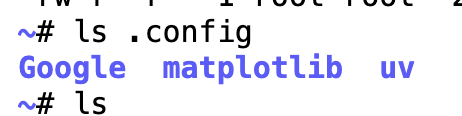

In [ ]:
# .config/ngrok created when you add token
!ngrok config add-authtoken {os.environ['NGROK_AUTH_TOKEN']}

In [ ]:
!ls ~/.config

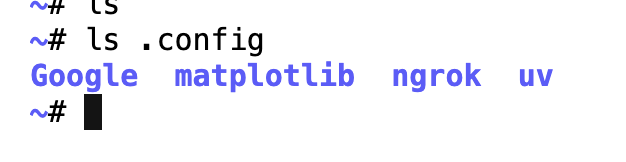

In [ ]:
%cp -r /content/drive/MyDrive/'Colab Notebooks'/.ssh /root/
# verify
%ls -al /root
# this copies the .ssh keys to /root for github clone


In [ ]:
# copy models from /drive/MyDrive/'Colab Notebooks'/.cache/huggingface to /root/.cache
#gigs will take a while
%cp -r /content/drive/MyDrive/'Colab Notebooks'/.cache/huggingface /root/.cache/
%ls -al /root/.cache/huggingface/hub

In [ ]:
# copy the ollama models to /root
%cp -r /content/drive/MyDrive/'Colab Notebooks'/.ollama /root/

In [ ]:
import os
# we only need ngrok.yml if we do ngrok start --all or if
# we specify ngrok.yml to hold the tunnel definitions
# Get the token from the environment variable
# If you are using Colab Secrets, ensure you've set NGROK_AUTH_TOKEN there first!
token = os.environ.get('NGROK_AUTH_TOKEN')

if not token:
    raise ValueError("NGROK_AUTH_TOKEN environment variable not found!")

# Use an f-string (notice the 'f' before the triple quotes)
config = f"""
version: "2"
region: us
authtoken: {token}

tunnels:
  ollama:
    proto: http
    addr: 11434
    host_header: localhost:11434
    domain: labrador-fair-trivially.ngrok-free.app
"""

# Ensure the directory exists
os.makedirs('/root/.config/ngrok', exist_ok=True)

with open('/root/.config/ngrok/ngrok.yml', 'w') as f:
    f.write(config)

print("✅ ngrok.yml updated with environment variable.")

In [ ]:
!ls /root/.config/ngrok

In [ ]:
!cat /root/.config/ngrok/ngrok.yml

```
ngrok.yml
~/.config/ngrok/ngrok.yml
!ngrok start --all
!curl https://labrador-fair-trivially.ngrok-free.app/api/generate -d '{ \
  "model": "qwen2.5:1.5b", \
  "prompt": "Write a short poem about a cat in space.", \
  "stream": false \
}'
```

In [ ]:
# install zstd for running ollama server
%%bash
set -e
apt-get install zstd
# Install ollama
curl -fsSL https://ollama.com/install.sh | sh

# Show version
ollama --version

# Start persistent server in background
# this doesnt stay up in anotehr cell?
# not reliable in colab but need it to download models
# we can run it using nohup or subprocess.Popen()

#nohup ollama serve > /tmp/ollama.log 2>&1 &


import subprocess, time, os, signal

print("Starting Ollama server...")
log = open("/tmp/ollama.log", "a", buffering=1)
p = subprocess.Popen(
    ["ollama", "serve"],
    stdout=log,
    stderr=log,
    start_new_session=True,  # detach from notebook process group
)
time.sleep(1)
print("PID:", p.pid, "alive:", p.poll() is None)



# Wait for server
sleep 2

# Pull model (downloads if missing)
ollama pull qwen3-vl

# Test API locally
curl -sS http://127.0.0.1:11434/api/chat \
  -H "Content-Type: application/json" \
  -d '{
    "model": "qwen3-vl",
    "messages": [{"role":"user","content":"Give me a 2-sentence summary of PPO."}],
    "stream": true
  }' | jq -r '.message.content // empty'

In [ ]:
# if downloading models make sure they are in /root/.ollama
# and store them in /content/drive/MyDrive/'Colab Notebooks' so
# we dont need to download them again

#!cp -r /root/.ollama/ /content/drive/MyDrive/'Colab Notebooks'

In [ ]:
#run in colab cli verify ollama running if not start with cell below
!ps -ef | grep -i 'ollama'

In [ ]:
#nohup command
#!nohup ollama serve > /tmp/ollama.log 2>&1 &

More ollama utils for port

In [ ]:
!!ss -ltnp | grep 11434 || true

In [ ]:
# this tests ollama server server port is localhost:11434
!curl -s http://127.0.0.1:11434/api/version

In [ ]:
!ss -ltnp | grep 11434 || true
!ps -ef | grep -i '[o]llama'

In [ ]:
!curl -s http://127.0.0.1:11434/api/tags | head

In [ ]:
import os, signal

# to stop if started with nohup
!pkill -f "ollama serve" || true
# we should have a reference to p.pid from popen
os.killpg(p.pid, signal.SIGTERM)  # because start_new_session=True makes pid==pgid

In [ ]:
# this is more stable than nohup?
import subprocess, time, os, signal

print("Starting Ollama server...")
log = open("/tmp/ollama.log", "a", buffering=1)
p = subprocess.Popen(
    ["ollama", "serve"],
    stdout=log,
    stderr=log,
    start_new_session=True,  # detach from notebook process group
)
time.sleep(1)
print("PID:", p.pid, "alive:", p.poll() is None)

In [ ]:
# can we start grok before installing and starting ollama? No because we customzied ngrok.yml for ollama
# this loops forever for debugging and starts all teh tunnels defined in ngrok.yml
!ngrok start --all

In [ ]:
# check if ngrok running, if not running will return empty
!ps -ef | grep -i '[n]grok'
!curl -s http://127.0.0.1:4040/api/tunnels | head -c 500; echo

In [ ]:
#check ollama server running
#!nohup ollama serve > /tmp/ollama.log 2>&1 &
!ollama list

In [ ]:
# Kill old ngrok
# 2 ways to start ngrok
# 1) the grok start all command which starts all the tunnels in ngrok.yml
# 2) ngrok start ollama. Ollama is the name of a specific tunnel in ngrok.yml
#
!pkill -f ngrok || true

# Start ngrok in background with explicit inspect port
!nohup ngrok start ollama \
    --config=/root/.config/ngrok/ngrok.yml \
    --log=stdout \
    --log-level=info \
    > /tmp/ngrok.log 2>&1 &

# Give it time to start
!sleep 5

# Verify ngrok process
!ps -ef | grep -i '[n]grok'

# Verify inspect API
!curl -s http://127.0.0.1:4040/api/tunnels | python3 -m json.tool

# If still nothing, print logs
!tail -n 50 /tmp/ngrok.log

In [ ]:
!tail -n 50 /tmp/ngrok.log

In [ ]:
# this tests the ngrok connection
%%bash
set -e
curl -sS http://127.0.0.1:4040/api/tunnels | jq .

In [ ]:
#ollama client
import requests

# Replace with your actual ngrok URL
NGROK_URL = "https://labrador-fair-trivially.ngrok-free.app"

try:
    response = requests.get(f"{NGROK_URL}/api/tags")
    if response.status_code == 200:
        print("✅ Connection Successful!")
        print("Models available:", response.json())
    else:
        print(f"❌ Connection failed with status code: {response.status_code}")
except Exception as e:
    print(f"❌ Error: {e}")

In [ ]:
#there are 2, ollama server and ollama client. This is ollama client
!pip -q install ollama

import ollama

client = ollama.Client(host='https://labrador-fair-trivially.ngrok-free.app')

stream = client.chat(
    model='qwen3-vl',
    messages=[{'role': 'user', 'content': 'Count from 1 to 20 slowly.'}],
    stream=True,
)

print("Assistant: ", end="")
for chunk in stream:
    print(chunk['message']['content'], end='', flush=True)

In [ ]:
!ollama list

In [ ]:
# converting to python colab cli version
# the cell is running the brower gym python server http.server
import os
import subprocess
import time
import requests

# 1. Set host to allow ngrok access
os.environ['OLLAMA_HOST'] = '0.0.0.0:11434'

# 2. Start Ollama as a background process
# Using Popen is generally more robust than threading for CLI daemons
print("Starting Ollama server...")
with open("/tmp/ollama.log", "w") as f:
    process = subprocess.Popen(["ollama", "serve"], stdout=f, stderr=f)

# 3. Wait for the server to be ready
for i in range(10):
    try:
        response = requests.get("http://localhost:11434/api/tags")
        if response.status_code == 200:
            print("✅ Ollama is up and running!")
            break
    except:
        time.sleep(2)
else:
    print("❌ Ollama failed to start. Check /tmp/ollama.log")

# 4. Pull the specific Vision model
print("Ensuring Qwen VL is pulled...")
subprocess.run(["ollama", "pull", "qwen2.5-vl:3b"])

In [ ]:
!git clone https://github.com/dougc333/BrowserGym

<ul>
<li>git clone https://github.com/dougc333/BrowserGym</li>
<li>cd BrowserGym</li>
<li>make setup-miniwob to install miniwob-plusplus dir</li>
<li>patch .env in BrowserGym to export MINIWOB_URL="http://127.0.0.1:8000/miniwob/" </li>
<li>from a colab cell run the miniwob server, cd /content/BrowserGym/miniwob-plusplus/miniwob/html</li>
<li>%cd /content/BrowserGym/miniwob-plusplus/miniwob/html
!nohup python3 -m http.server 8000 --bind 127.0.0.1 > /content/miniwob_http.out 2> /content/miniwob_http.err &</li>
<li>if you run python -m http.server 8000 make sure you are in the html subdirectory first. else the server will display what is in content. </li>
<li>run a curl request to test !curl -sS http://127.0.0.1:8000/miniwob/ | head -n 30</li>
<li>Should see a dir of the html tests</li>
</ul>
#we need the http miniwob server running in a cell either in foreground or background

In [ ]:
%cd /content/BrowserGym/miniwob-plusplus/miniwob/html
#!nohup python -m http.server 8000
#!nohup python3 -m http.server 8000 > /dev/null 2>&1 &
!nohup python3 -m http.server 8000 > server.log 2>&1 &

In [ ]:
!tail %cd /content/BrowserGym/miniwob-plusplus/miniwob/html/server.log

In [ ]:
%%bash
set -e
# doesnt work from here, make sure to run this in colab terminal
export MINIWOB_URL="http://localhost:8000/miniwob/"

In [ ]:
import requests

# This asks the local Ollama server about the models currently in memory
response = requests.get("http://localhost:11434/api/ps")
print(response.json())